### **Pytorch workflow**

What we re going to cover:
1. data (prepare to load)
2. build model
3. fitting the model to data (training)
4. making predictions and evaluating a model (inference)
5. saving and loading a model
6. putting it all together

In [ ]:
import torch
from torch import nn    # contains pytorch building blocks for neuronal links
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

### 1. Data preparing and loading

In [ ]:
# create know parameters
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

### **Slitting data into training and test sets (IMPORTANT CONCEPT OF ML in general)**

In [ ]:
# create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

Data explorer Motto

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  # plots training data, test and compare
  plt.figure(figsize=(10, 7))

  #plot training data
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  #plot testing data
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # predictions
  if predictions is None:
    plt.plot(test_data, test_labels, c="r", label="Predictions")
  else:
    plt.plot(test_data, predictions, c="r", label="Predictions")

  plt.legend(prop={"size": 14})


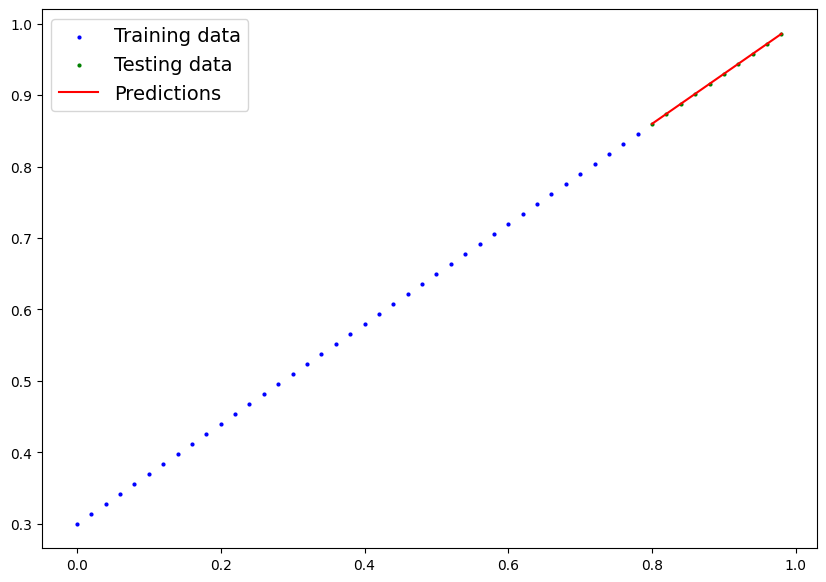

In [ ]:
plot_predictions();

## 2. Build a model


In [ ]:
from torch import nn

# create a linear regression model class
class LinearRegressionModelV1(nn.Module):
  def __init__(self):
    super().__init__()

    self.weight = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias

### Checking the content of our model


In [ ]:
# random seed
torch.manual_seed(42)

# create a instance of the model (a subclass of nn.Module)
model_0 = LinearRegressionModelV1()

#check parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# list named parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Making predictions using 'torch.inference_mode()'

In [ ]:
# make predictions with the model
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

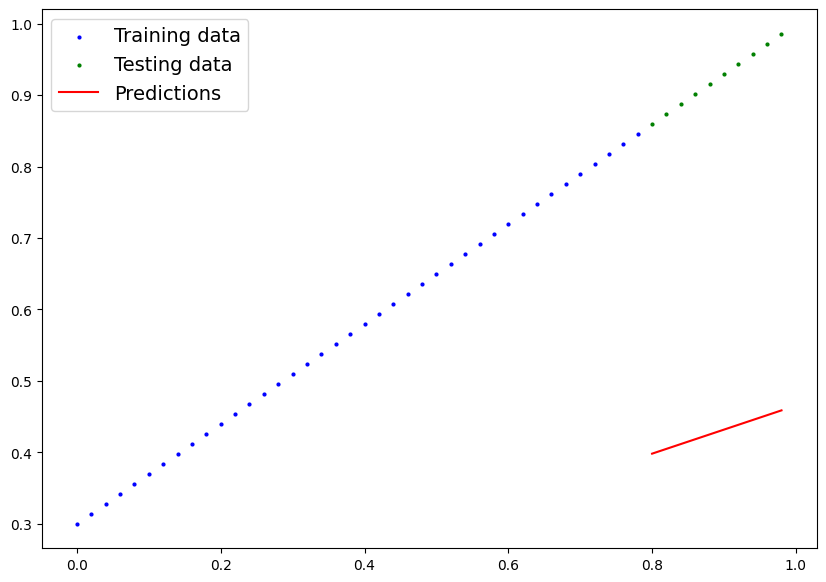

In [ ]:
plot_predictions(predictions=y_preds)

### 3. Train model

THe idea of training a model is for move from some *unknown* parameter to some *know* parameters.

better representation of the data

ne way to measure how poor or wrong your models predictions are is to use a loss function.

Things we need to train:

* **Loss function:** A function to measure how wrong your model predictions are to the ideal outputs, lower is better
* **Optimizer:** Takes into account the loss of a model and adjust the model parameters (eg weight and bias)
  - in optimizer you need to set 2 parameters

    - `params:` params youd like to optimize
    - `lr`(learning rate): defines big/small changes in parameters

For pytorch we need:
- a training lopp
- a testing loop

In [ ]:
#check model parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# setup loss function
loss_fn = nn.L1Loss()

# setup optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # lr = learning rate = important hyper parameter

### Build a training loop (and testing loop)

0. loop throught the data and do...
1. forward pass (involves data into our model `forward()`) to make predictions on propagation
2. calculate the loss
3. optimizer zero grad
4. loss backward
5. optimizer step-use



In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
epochs = 100

# track direrent values
epochs_count = []
loss_values = []
test_loss_values = []

### training

# 0 loop throught data
for epoch in range(epochs):
  # set model to training mode
  model_0.train()

  # 1 forward pass
  y_preds = model_0(X_train)

  # 2 calculate the loss
  loss = loss_fn(y_preds, y_train)

  # 3 optimize zero grad
  optimizer.zero_grad()

  # 4 loss backward
  loss.backward()

  # 5 optimizer step
  optimizer.step()

  ### testing
  model_0.eval()
  with torch.inference_mode():

    # 1 do forward pass
    test_preds = model_0(X_test)

    # 2 calculate the loss
    test_loss = loss_fn(test_preds, y_test)

  # Record values for plotting
  epochs_count.append(epoch)
  loss_values.append(loss.detach().numpy()) # Detach and convert to numpy for plotting
  test_loss_values.append(test_loss.detach().numpy()) # Detach and convert to numpy for plotting

  # Print progress
  print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test loss: {test_loss:.4f}")
  # print model state (optional, uncomment if needed for debugging)
  # print(model_0.state_dict())

Epoch: 0 | Loss: 0.3129 | Test loss: 0.4811
Epoch: 1 | Loss: 0.3014 | Test loss: 0.4676
Epoch: 2 | Loss: 0.2898 | Test loss: 0.4541
Epoch: 3 | Loss: 0.2783 | Test loss: 0.4407
Epoch: 4 | Loss: 0.2668 | Test loss: 0.4272
Epoch: 5 | Loss: 0.2553 | Test loss: 0.4137
Epoch: 6 | Loss: 0.2438 | Test loss: 0.4002
Epoch: 7 | Loss: 0.2322 | Test loss: 0.3868
Epoch: 8 | Loss: 0.2207 | Test loss: 0.3733
Epoch: 9 | Loss: 0.2092 | Test loss: 0.3598
Epoch: 10 | Loss: 0.1977 | Test loss: 0.3464
Epoch: 11 | Loss: 0.1862 | Test loss: 0.3329
Epoch: 12 | Loss: 0.1746 | Test loss: 0.3194
Epoch: 13 | Loss: 0.1631 | Test loss: 0.3059
Epoch: 14 | Loss: 0.1516 | Test loss: 0.2925
Epoch: 15 | Loss: 0.1401 | Test loss: 0.2790
Epoch: 16 | Loss: 0.1285 | Test loss: 0.2655
Epoch: 17 | Loss: 0.1170 | Test loss: 0.2521
Epoch: 18 | Loss: 0.1061 | Test loss: 0.2396
Epoch: 19 | Loss: 0.0968 | Test loss: 0.2282
Epoch: 20 | Loss: 0.0891 | Test loss: 0.2173
Epoch: 21 | Loss: 0.0823 | Test loss: 0.2070
Epoch: 22 | Loss: 0.

In [ ]:
import numpy as np
np.array(loss_values), np.array(test_loss_values)

(array([0.31288138, 0.30136034, 0.28983936, 0.27831835, 0.26679736,
        0.25527635, 0.24375534, 0.23223433, 0.22071333, 0.20919232,
        0.19767132, 0.18615034, 0.17462933, 0.16310832, 0.15158734,
        0.14006636, 0.12854536, 0.11702438, 0.10609122, 0.09681284,
        0.08908726, 0.08227583, 0.07638873, 0.07160007, 0.06747635,
        0.06395438, 0.06097005, 0.05845819, 0.05635259, 0.05458578,
        0.05314853, 0.05181945, 0.05069301, 0.04982285, 0.04895269,
        0.04819351, 0.04753182, 0.04692793, 0.04642332, 0.04591871,
        0.04543797, 0.04503796, 0.04463796, 0.04423796, 0.04383796,
        0.04343796, 0.04307463, 0.04272563, 0.04237663, 0.04202763,
        0.04167863, 0.04132963, 0.04098063, 0.04063163, 0.04028264,
        0.03993364, 0.03958464, 0.03923564, 0.03888664, 0.03853764,
        0.03818933, 0.03785244, 0.03750344, 0.03716412, 0.03681822,
        0.03647511, 0.03613304, 0.0357861 , 0.03544784, 0.03509884,
        0.0347609 , 0.03441364, 0.03407188, 0.03

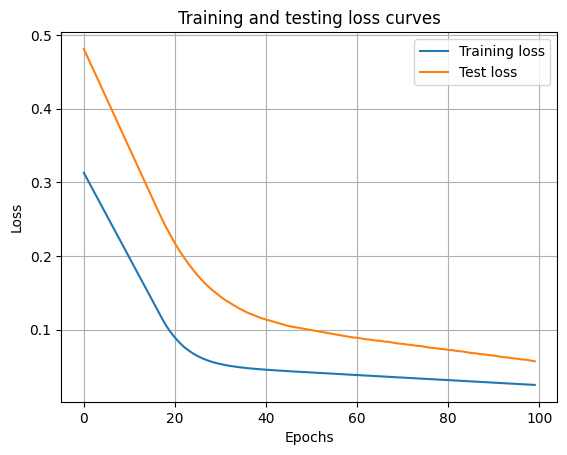

In [ ]:
# plot the loss curves
plt.plot(epochs_count, loss_values, label="Training loss")
plt.plot(epochs_count, test_loss_values, label="Test loss")
plt.title("Training and testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.grid()
plt.legend();

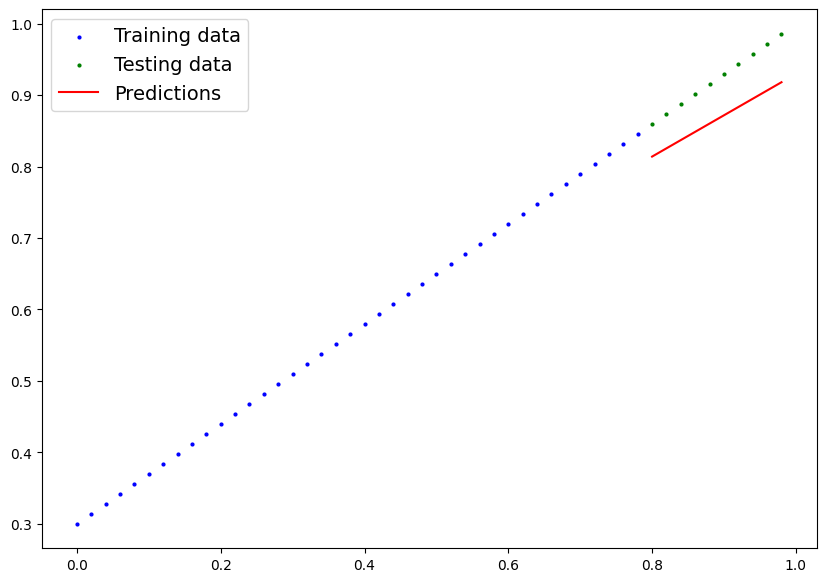

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

plot_predictions(predictions=y_preds_new)

## Saving a model in pytorch

In [ ]:
# saving our model
from pathlib import Path

# 1 create model diretory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2 create model save path
MODEL_NAME = "01_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3 save the model
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model.pth


### Loading a pytorch model

In [ ]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [ ]:
# to load in a saved state_dict we need to instantiate a new instace
loaded_model_0 = LinearRegressionModelV1()

# load the saved model
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [ ]:
# make predictions with our loaded model
loaded_model_0.eval()

with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [ ]:
# compare loaded model preds with original preds on the test data
y_preds_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. putting it all togheter


In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

create device-agnostic code

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device: {device}")

using device: cuda


## 6.1 DATA

In [ ]:
# create data using linear regression formula
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [1]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  # plots training data, test and compare
  plt.figure(figsize=(10, 7))

  #plot training data
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  #plot testing data
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # predictions
  if predictions is not None:
    plt.plot(test_data, predictions, c="r", label="Predictions")

  plt.legend(prop={"size": 14})

NameError: name 'X_train' is not defined

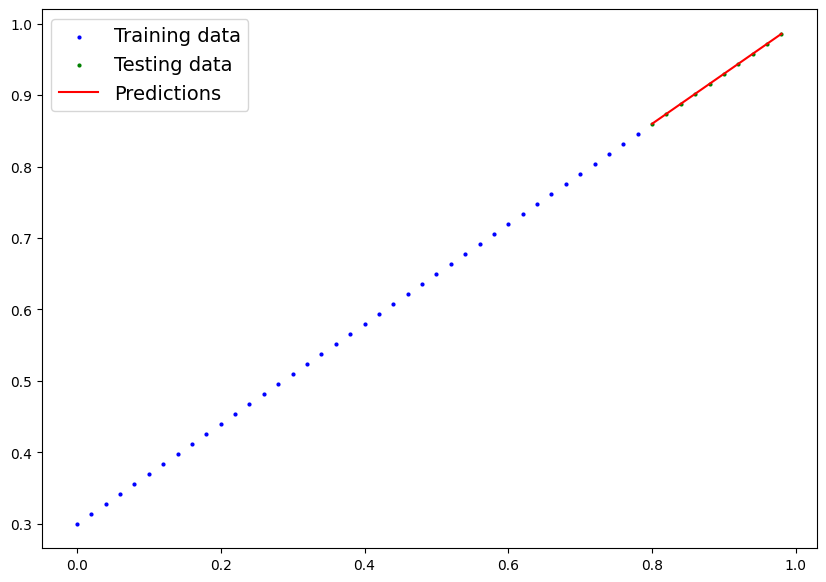

In [ ]:
# plot the data
plot_predictions(X_train, y_train, X_test, y_test)

## 6.2 building a pytorch linear model

In [ ]:
class LinearRegresionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# set the seed
torch.manual_seed(42)

# create an instance of the model
model_1 = LinearRegresionModelV2()
model_1, model_1.state_dict()

(LinearRegresionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# check current device
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
# set to target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

## 6.3 Training
  - Loss function
  - Optimizer
  - Training loop
  - Training loop

In [ ]:
# loss function
loss_fn = nn.L1Loss()

# optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [ ]:
# training loop
torch.manual_seed(42)

epochs = 200

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # 1 forward pass
  y_preds = model_1(X_train)

  # 2 calculate the loss
  loss = loss_fn(y_preds, y_train)

  # 3 optimizer zero grad
  optimizer.zero_grad()

  # 4 loss backward
  loss.backward()

  # 5 optimizer step
  optimizer.step()

  ### Testing
  model_1.eval()

  with torch.inference_mode():
    test_preds = model_1(X_test)
    test_loss = loss_fn(test_preds, y_test)

  # Print progress
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test loss: {test_loss:.4f}")

Epoch: 0 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 10 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 20 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 30 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 40 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 50 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 60 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 70 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 80 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 90 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 100 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 110 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 120 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 130 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 140 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 150 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 160 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 170 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 180 | Loss: 0.0013 | Test loss: 0.0138
Epoch: 190 | Loss: 0.0013 | Test loss: 0.0138


In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
weight, bias

(0.7, 0.3)

## 6.4 Making and evaluating predictions

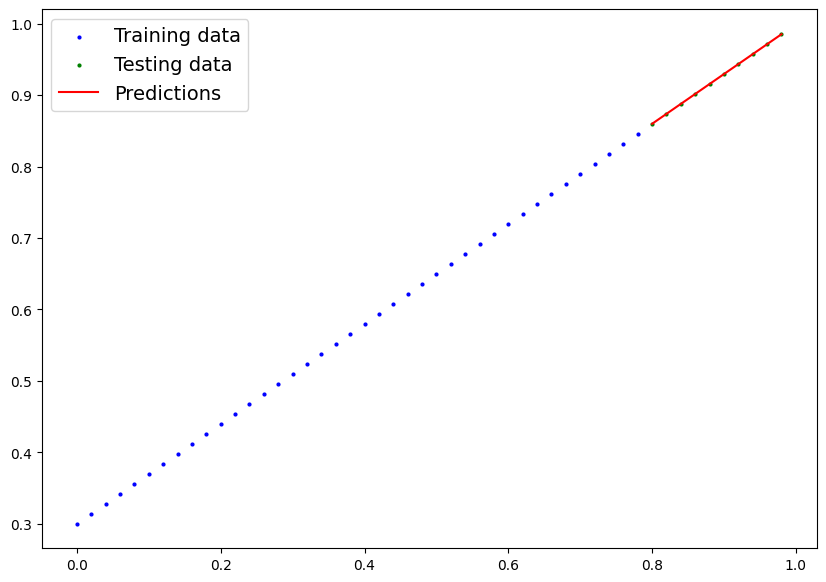

In [ ]:
# turn into evaluation
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

plot_predictions(predictions=y_preds.cpu())

## 6.5 Saving & loading a trained model


In [ ]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_2.pth


In [ ]:
# load model
loaded_model_1 = LinearRegresionModelV2()

# load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# put model device
loaded_model_1.to(device)

LinearRegresionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)